El dataset  muestra la eficiencia en quema de calorias de varios pacientes junto con los registros de sus habitos, registros fisicos y medicos.

La matriz cuenta con 161845 entradas y 15 columnas detalladas a continuación:

* Age: edad del paciente
* steps_per_day: pasos diarios
* active_minutos: minutos de actividad fisica
* calories_burned: calorias quemadas a lo largo del dia
* sleep_hours: horas de sueño
* hydration_liter: litros de agua consumidos al dia
* bmi: indice de masa corporal
* workouts_per_week: sesiones de entrenamiento mensual
* muscle_mass_ratio: relacion musculo/peso
* body_fat_percentage: porcentaje de grasa muscular
* heart_rate_resting: latidos en estado basal
* heart_rate_avg: latidos promedio en el dia
* continuous_exercise_days: dias continuos de ejercicio
* efficiency_score: puntaje de eficiencia de quemado de calorias
* calorie_efficiency: categorizacion de eficiencia de quemado de calorias

Fuente: https://www.kaggle.com/datasets/parasharmanu/close-to-realistic-calorie-efficiency-dataset

## Sección 0 — Configuración inicial

In [ ]:
# ============================================================
#   PARÁMETROS
# ============================================================
FILEPATH     = 'dataset3_calorie_efficiency_dataset.csv'
TARGET       = 'calorie_efficiency'
TEST_SIZE    = 0.2
RANDOM_STATE = 42


In [ ]:
# ============================================================
#   IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.pipeline         import make_pipeline
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, classification_report,
                                       ConfusionMatrixDisplay, roc_curve)
from scipy.stats              import randint, uniform

print('✅ Imports OK')

✅ Imports OK


In [ ]:
# ============================================================
#   CARGA DE DATOS
# ============================================================
df = pd.read_csv(FILEPATH)
df = df.reset_index(drop=True)

print(f'Shape: {df.shape}')
display(df.head())
print()
display(df.tail())

Shape: (161845, 15)


,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency


,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
161840,42,4975,42,1500,6.85,2.68,24.75,3,0.437,0.142,71.5,116.3,3,1.050,Low Efficiency
161841,19,7731,82,1500,6.94,2.70,18.18,2,0.398,0.348,65.5,89.9,1,0.763,Low Efficiency
161842,52,7285,72,1500,7.31,1.23,22.38,3,0.450,0.083,68.1,106.0,2,0.671,Low Efficiency
161843,63,5632,36,1500,7.15,1.45,20.83,4,0.237,0.251,69.1,104.7,2,0.918,Low Efficiency
161844,35,6767,66,1500,7.25,1.42,30.95,1,0.316,0.050,70.8,111.4,7,0.880,Low Efficiency


---
## Sección I — Exploración y Limpieza (EDA)

### I.1 — Información general

In [ ]:
print('================================= Info =================================')
df.info()
print()
print('================================= Describe =================================')
display(df.describe().T)
print('================================= Variables Categóricas =================================')
cat_cols = df.select_dtypes(include='object').columns
cat_stats = pd.DataFrame({
    'n_unique'  : df[cat_cols].nunique(),
    'moda'      : df[cat_cols].mode().iloc[0],
    'frec_moda' : df[cat_cols].apply(lambda x: x.value_counts().iloc[0]),
    'pct_moda'  : df[cat_cols].apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100).round(1),
})
display(cat_stats)

# Tipos de datos correctos
# columnas numericas en rangos posibles, destacar caso curioso que calories_burned es siempre 1500
# 1 variable categorica (target) con 3 posibilidades

================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161845 entries, 0 to 161844
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       161845 non-null  int64  
 1   steps_per_day             161845 non-null  int64  
 2   active_minutes            161845 non-null  int64  
 3   calories_burned           161845 non-null  int64  
 4   sleep_hours               161845 non-null  float64
 5   hydration_liters          161845 non-null  float64
 6   bmi                       161845 non-null  float64
 7   workouts_per_week         161845 non-null  int64  
 8   muscle_mass_ratio         161845 non-null  float64
 9   body_fat_percentage       161845 non-null  float64
 10  heart_rate_resting        161845 non-null  float64
 11  heart_rate_avg            161845 non-null  float64
 12  continuous_exercise_days  1

,count,mean,std,min,25%,50%,75%,max
age,161845.0,40.981711,13.553389,18.00,29.000,41.00,53.000,64.000
steps_per_day,161845.0,6995.207445,2480.258102,1000.00,5303.000,6993.00,8669.000,18659.000
active_minutes,161845.0,69.628231,28.574252,10.00,50.000,69.00,89.000,180.000
calories_burned,161845.0,1500.000000,0.000000,1500.00,1500.000,1500.00,1500.000,1500.000
sleep_hours,161845.0,6.499140,1.198186,3.00,5.690,6.49,7.310,10.000
hydration_liters,161845.0,2.502037,0.793862,0.50,1.960,2.50,3.040,5.000
bmi,161845.0,24.228216,5.370827,16.00,20.080,24.03,27.940,40.000
workouts_per_week,161845.0,2.986036,1.682844,0.00,2.000,3.00,4.000,7.000
muscle_mass_ratio,161845.0,0.350772,0.077725,0.20,0.296,0.35,0.404,0.600
body_fat_percentage,161845.0,0.250450,0.097356,0.05,0.183,0.25,0.317,0.500


================================= Variables Categóricas =================================


,n_unique,moda,frec_moda,pct_moda
calorie_efficiency,3,Low Efficiency,151990,93.9


### I.2 — Duplicados

In [ ]:
n_dup = df.duplicated().sum()
print(f'Filas iniciales : {len(df)}')
print(f'Duplicados      : {n_dup} ({n_dup/len(df)*100:.2f}%)')

if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Filas tras limpieza: {len(df)}')
else:
    print('Sin duplicados ✓')

Filas iniciales : 161845
Duplicados      : 0 (0.00%)
Sin duplicados ✓


### I.3 — Nulos

In [ ]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje': pct}).query('nulos > 0')
display(nulos_df if not nulos_df.empty else pd.DataFrame({'resultado': ['Sin nulos ✓']}))


,resultado
0,Sin nulos ✓


### I.4 — Inconsistencias categóricas

In [ ]:
# no hay problemas con las columnas categoricas

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('================================= Value Counts =================================\n')
for col in cat_cols:
    print(f'===== {col} =====')
    display(df[col].value_counts())
    print()

print('================================= Verificación de capitalización =================================\n')
for col in cat_cols:
    original = df[col].nunique()
    lower    = df[col].str.lower().nunique()
    if original != lower:
        print(f"  ⚠️  INCONSISTENCIA en '{col}': {original} vs {lower}")
        df[col] = df[col].str.strip().str.lower()
    else:
        print(f"  '{col}': sin inconsistencias ✓")

================================= Value Counts =================================

===== calorie_efficiency =====


,count
calorie_efficiency,
Low Efficiency,151990
Moderate,5579
High Efficiency,4276



================================= Verificación de capitalización =================================

  'calorie_efficiency': sin inconsistencias ✓


### I.5 — Outliers (IQR)

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()

outlier_report = []
for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'columna': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                           'lim_inf': round(lower,2), 'lim_sup': round(upper,2),
                           'outliers': n_out, 'pct': round(n_out/len(df)*100,2)})
display(pd.DataFrame(outlier_report))


,columna,Q1,Q3,lim_inf,lim_sup,outliers,pct
0,age,29.00,53.00,-7.00,89.00,0,0.00
1,steps_per_day,5303.00,8669.00,254.00,13718.00,554,0.34
2,active_minutes,50.00,89.00,-8.50,147.50,577,0.36
3,calories_burned,1500.00,1500.00,1500.00,1500.00,0,0.00
4,sleep_hours,5.69,7.31,3.26,9.74,1149,0.71
5,hydration_liters,1.96,3.04,0.34,4.66,569,0.35
6,bmi,20.08,27.94,8.29,39.73,369,0.23
7,workouts_per_week,2.00,4.00,-1.00,7.00,0,0.00
8,muscle_mass_ratio,0.30,0.40,0.13,0.57,551,0.34
9,body_fat_percentage,0.18,0.32,-0.02,0.52,0,0.00


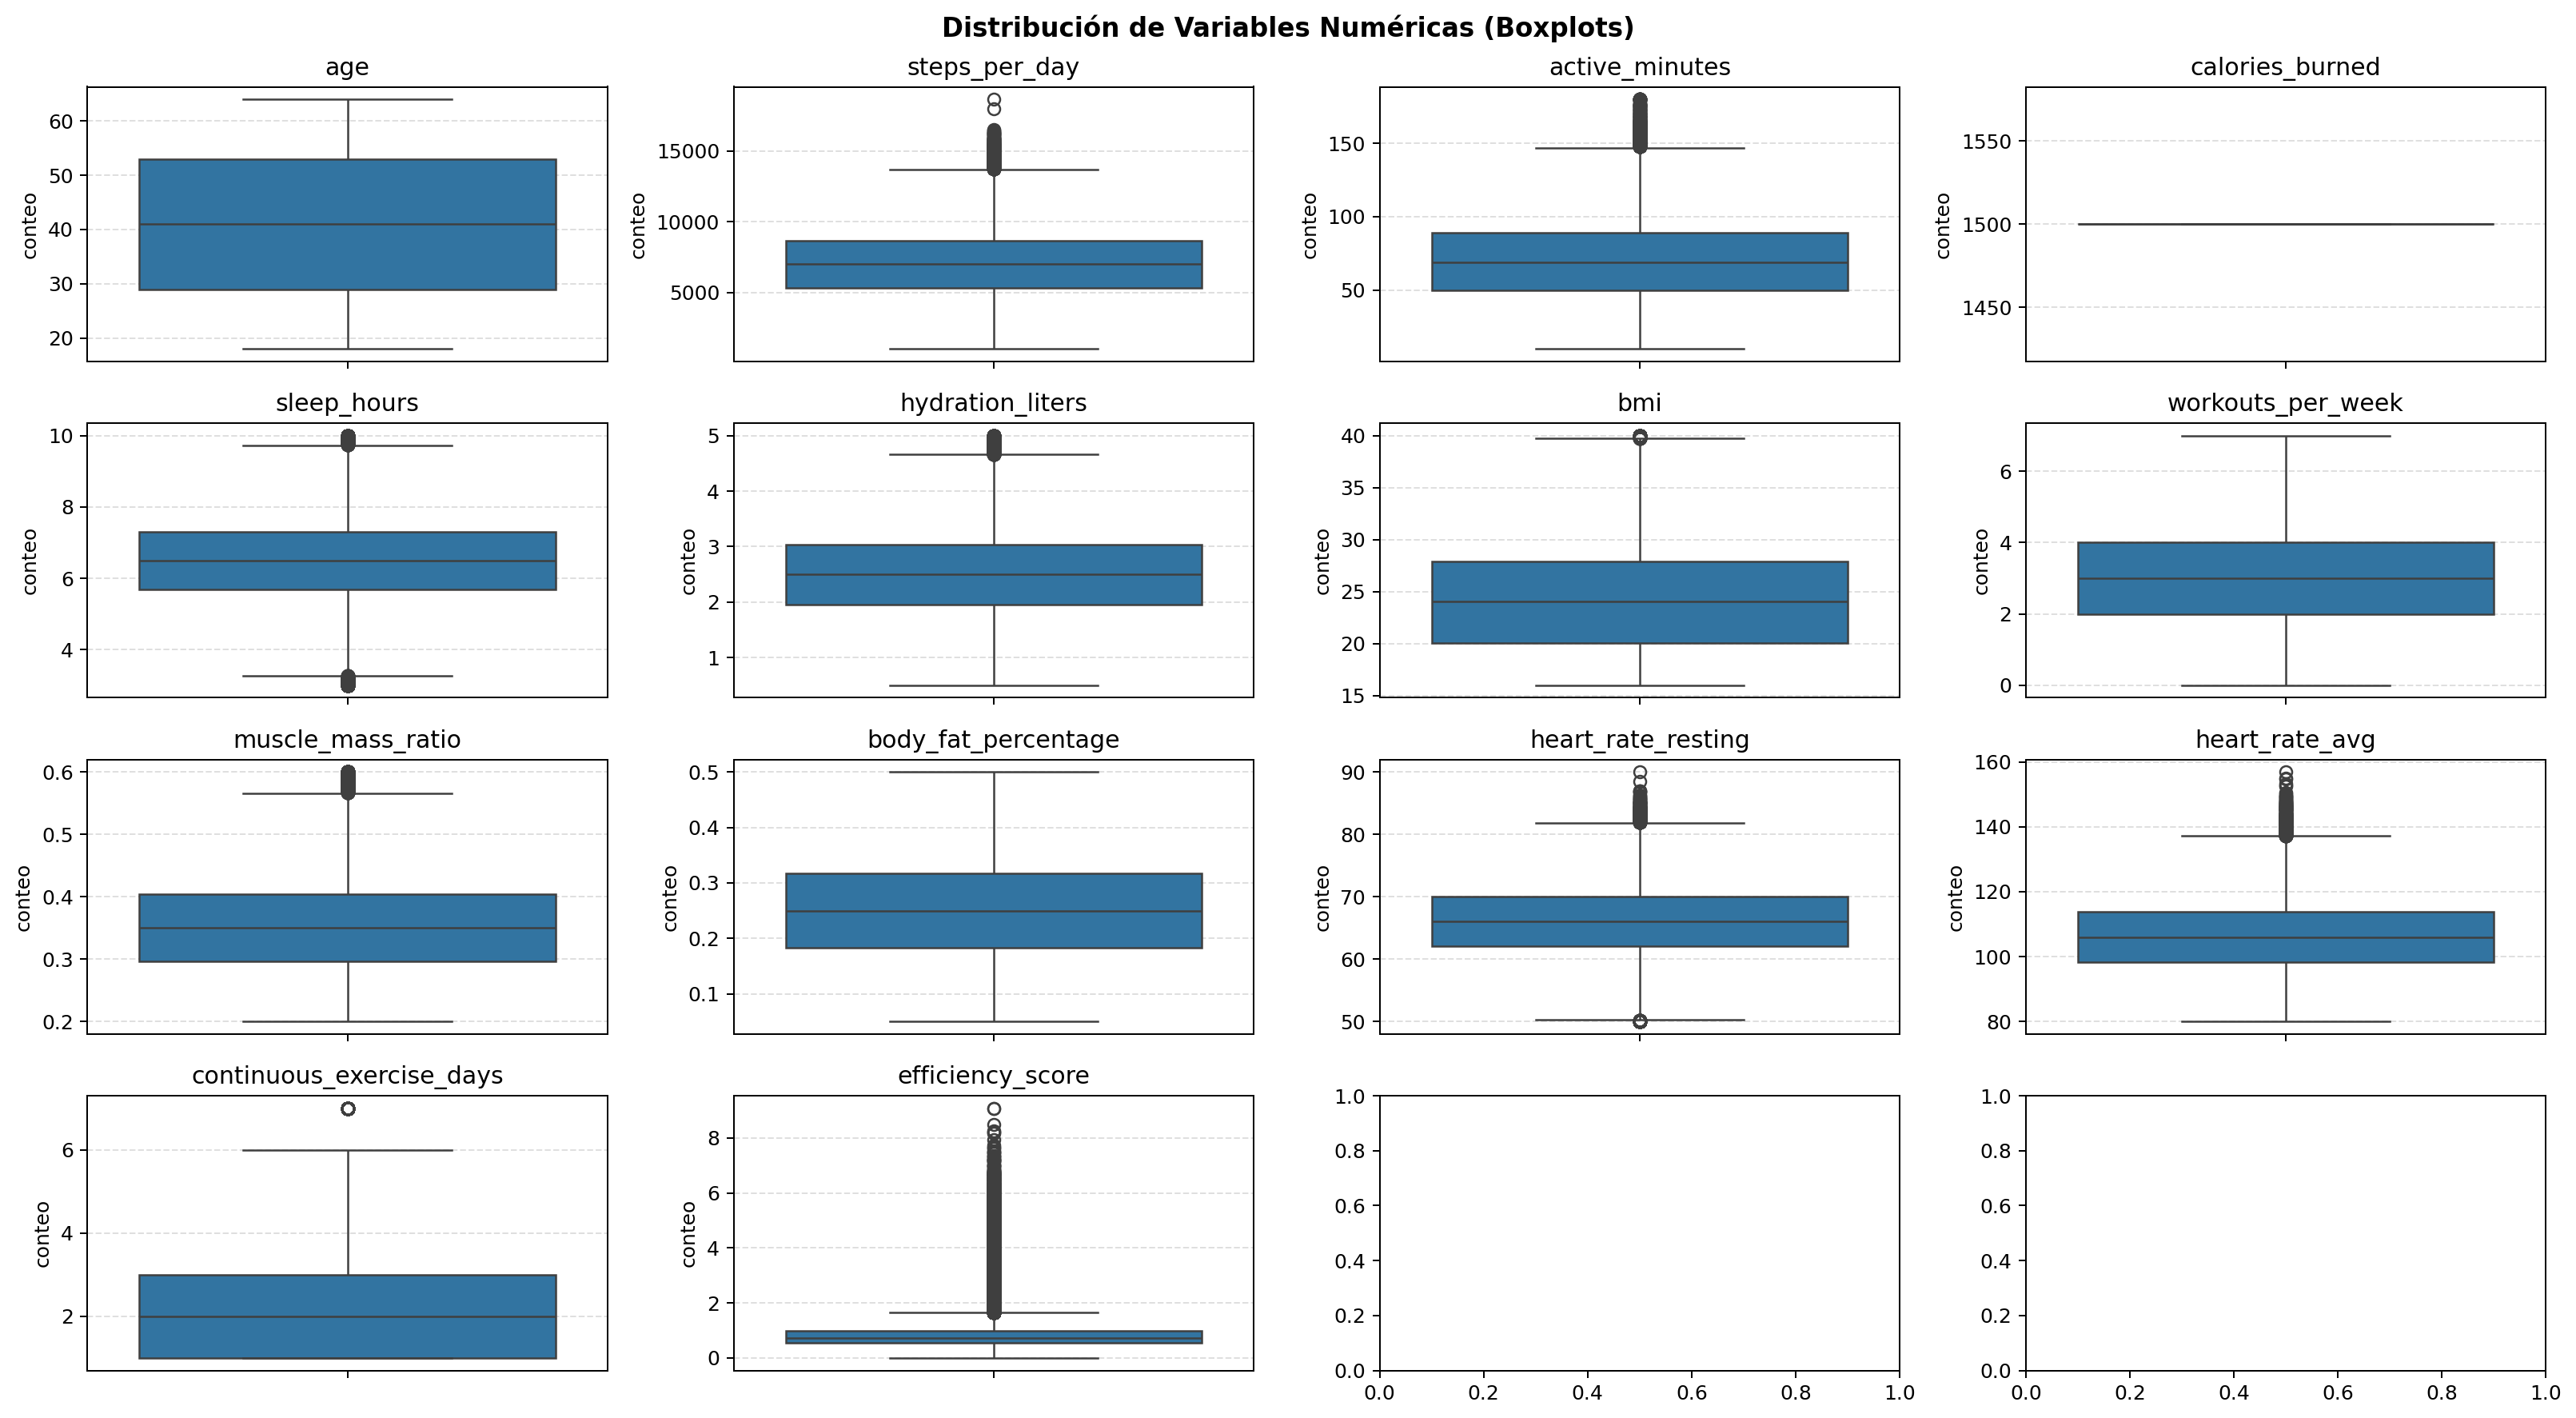

In [ ]:
# boxplots  variables vs salud mental
fig, axes = plt.subplots(4, 4, figsize=(18, 10), dpi=180)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel('conteo')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Numéricas (Boxplots)', fontsize=13, fontweight='bold')
print()
plt.tight_layout(); plt.show()

Outliers dentro de rangos esperables, pueden ser individuos con capacidades fisicas excepcionales o con una vida muy sedentaria, para este caso se mantendran todos los outliers.

### I.6 — Distribución

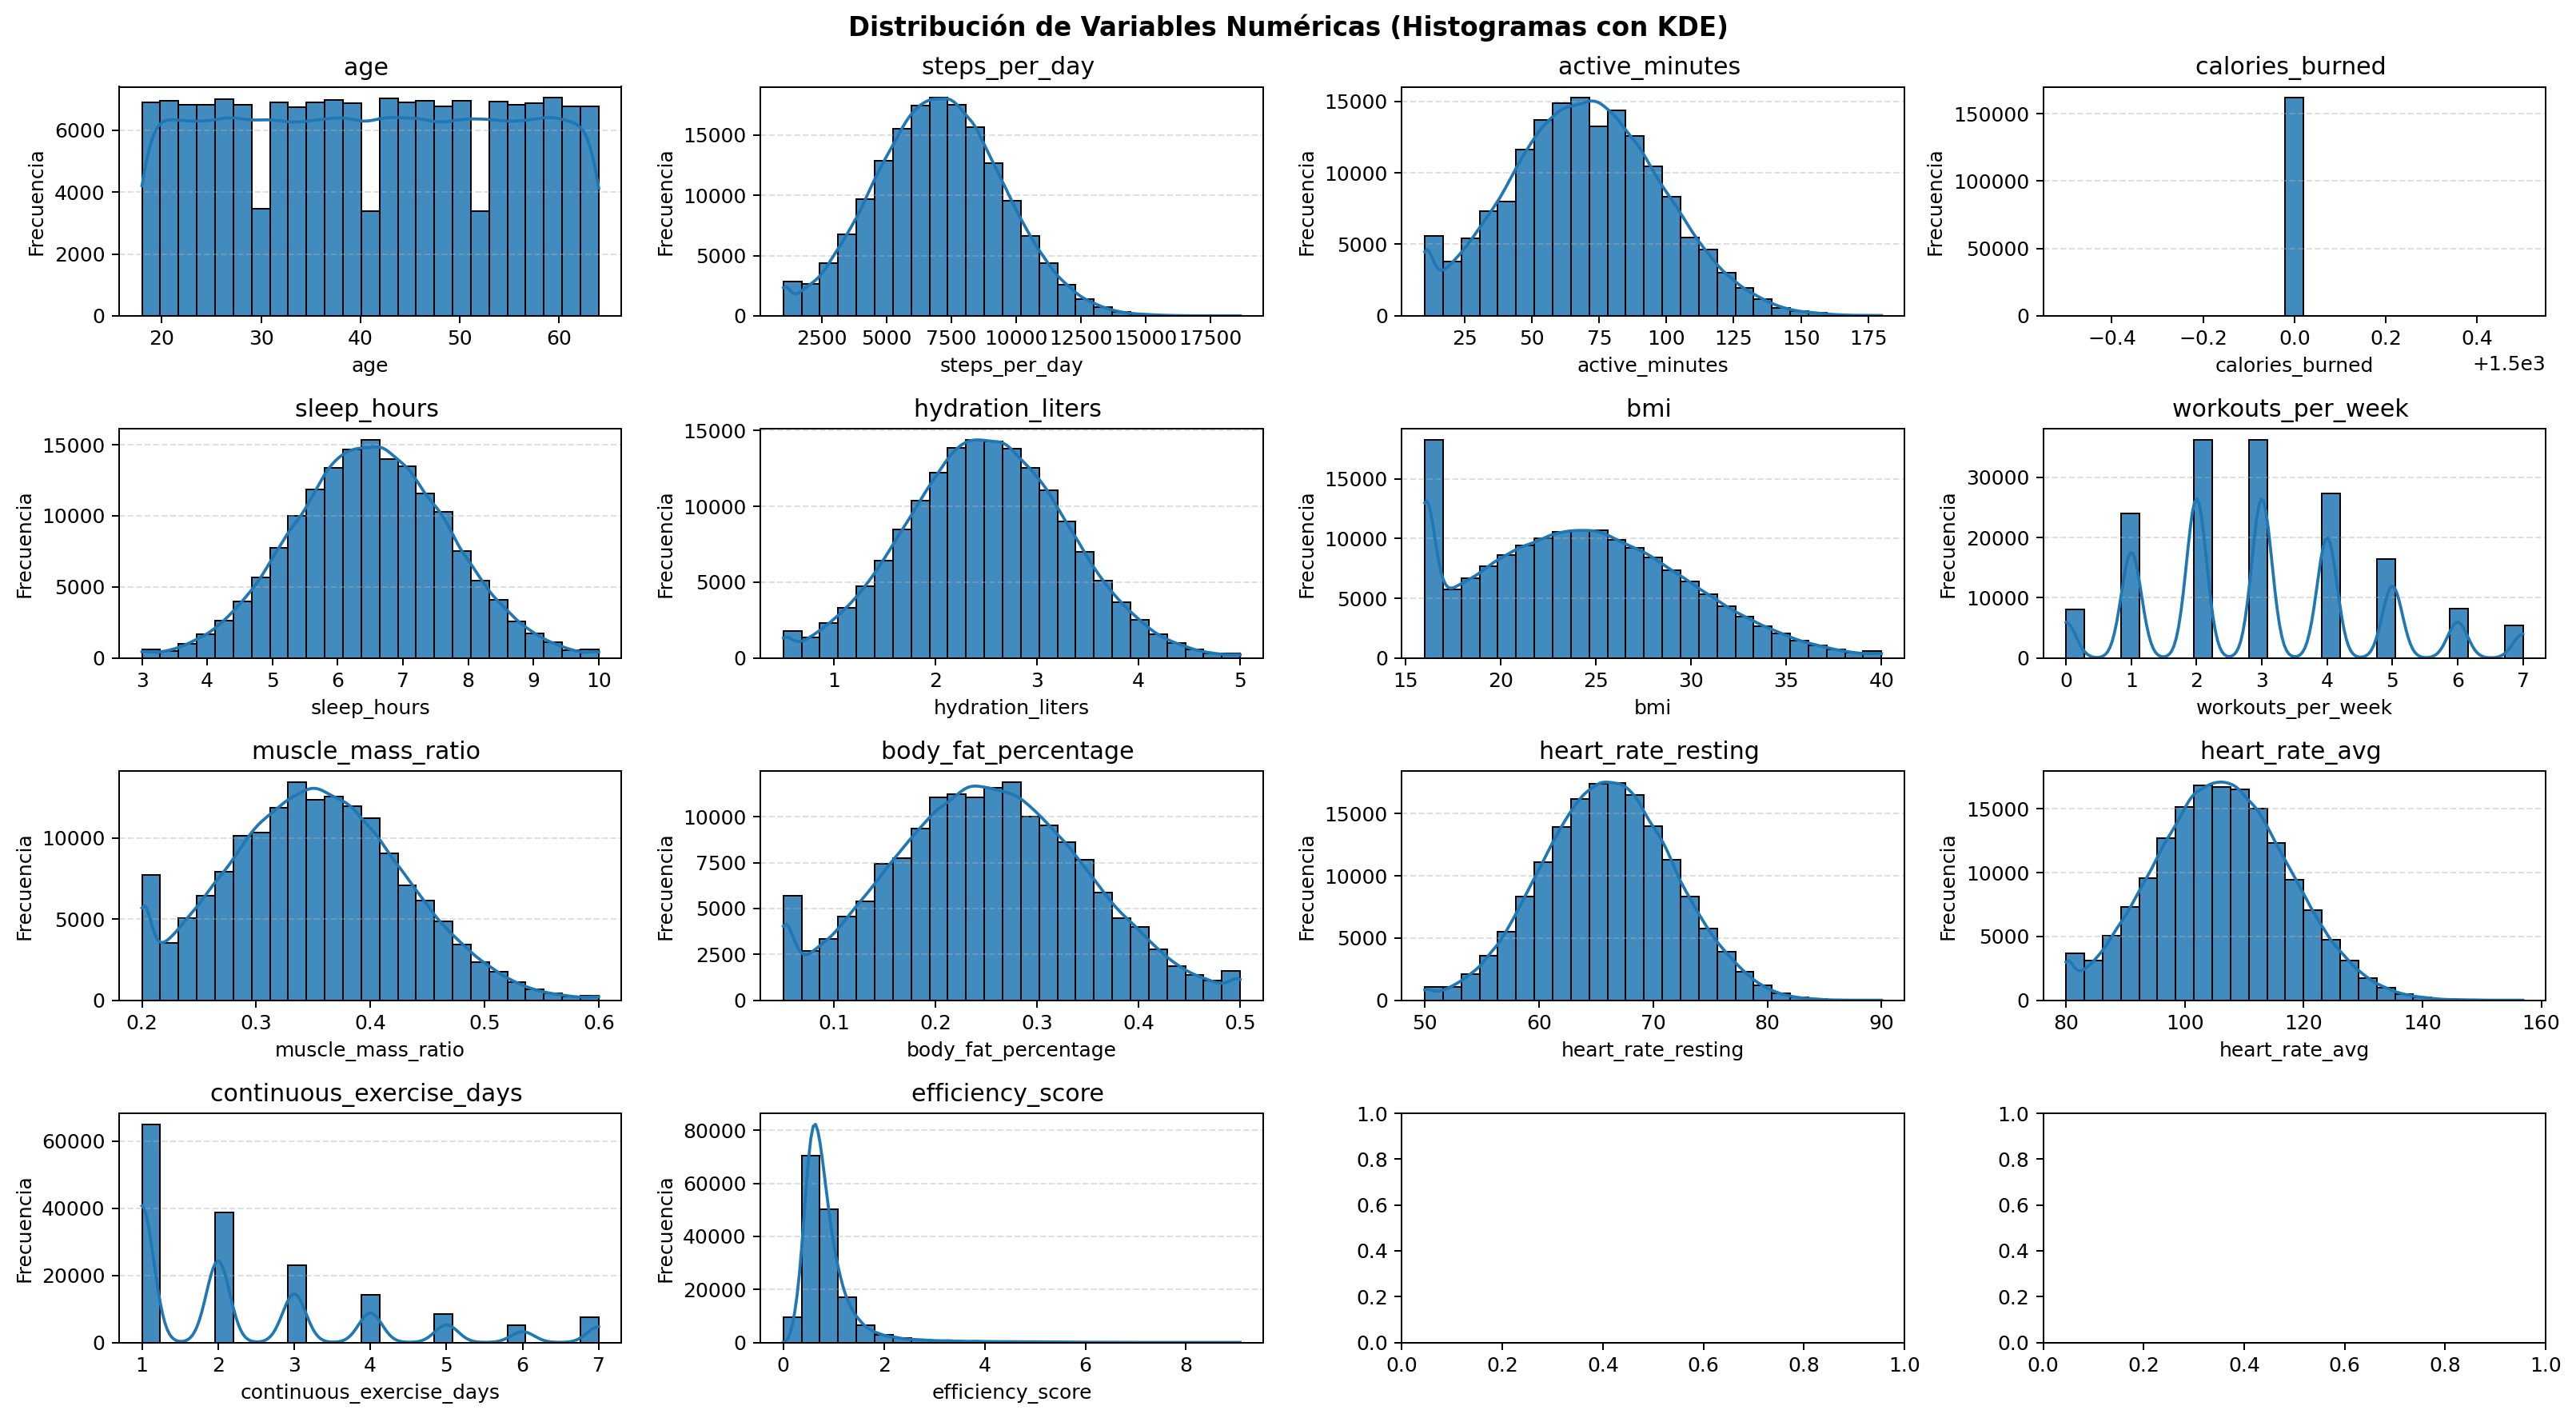

In [ ]:
# Variables numericas
fig, axes = plt.subplots(4, 4, figsize=(18, 10), dpi=180)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=25, ax=ax, kde=True, alpha=0.85)
    ax.set_title(f'{col} ')
    ax.set_xlabel(col); ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Numéricas (Histogramas con KDE)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



* La mayoria de graficos presentan una distribucion normal exceptuando la edad y los dias continuos de ejercicio.
* La mayoria de individuos poseen una capacidad bastante deficiente de quemar calorias, puede deberse al estandar de sedentarismo actual de la sociedad.
* Los individuos sostienen dificultades para hacer ejercicios continuamente y suele hacerlo en 2 y 3 veces a la semana.

### I.7 — Variable objetivo: calorie_efficiency

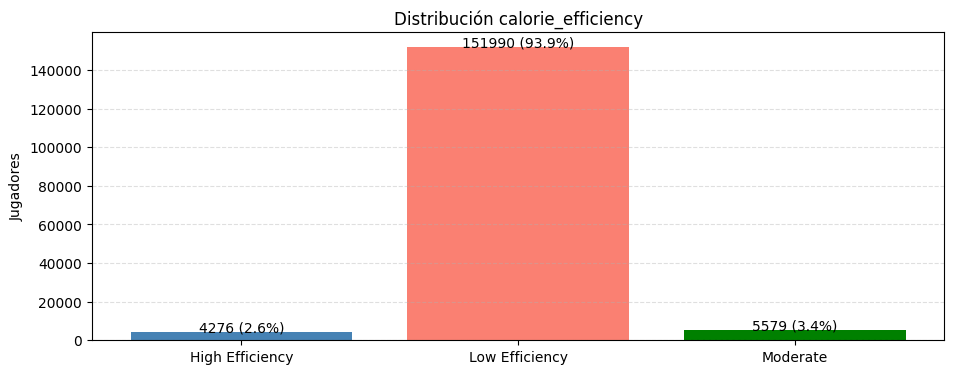

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(11, 4), dpi=100)

counts = df['calorie_efficiency'].value_counts().sort_index()
axes.bar(counts.index, counts.values,
            color=['steelblue', 'salmon', 'green'], edgecolor='none')
axes.set_title('Distribución calorie_efficiency', fontsize=12)
axes.set_ylabel('Jugadores')
axes.grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(counts.values):
    axes.text(i, v + 1, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

Matriz bastante desbalanceada, lo que dificultara la clasificacion por parte del modelo, se requerira estratificar para asegurar una buena prediccion. Como se menciono antes una eficiencia baja es esperable con el estandar sedentario actual

### I.8 — Heatmap correlación

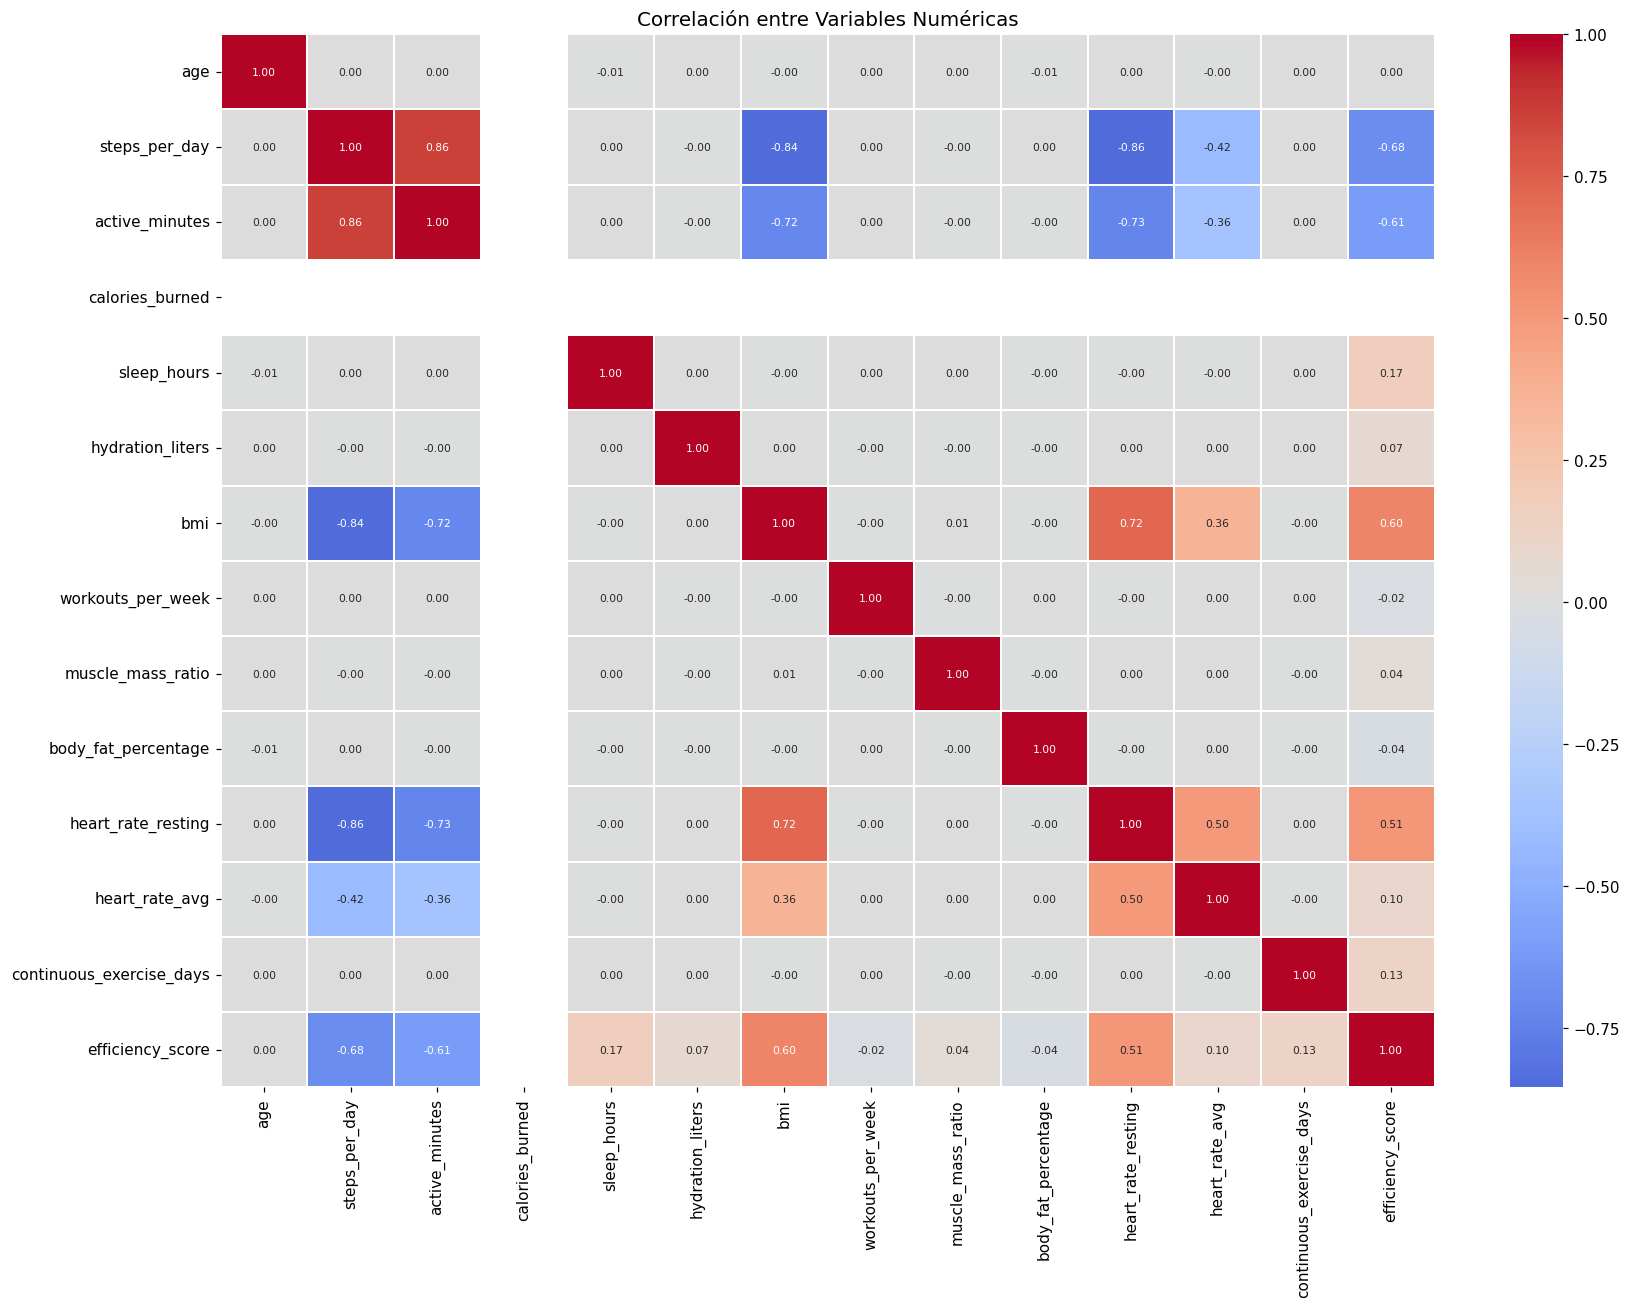


Correlaciones más fuertes con efficiency_score:
steps_per_day              -0.681
active_minutes             -0.613
bmi                         0.601
heart_rate_resting          0.513
sleep_hours                 0.173
continuous_exercise_days    0.129
heart_rate_avg              0.100
hydration_liters            0.069
muscle_mass_ratio           0.043
body_fat_percentage        -0.041


In [ ]:
num_for_corr = df.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(16, 12), dpi=110)
sns.heatmap(df[num_for_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.3, annot_kws={'size':7})
plt.title('Correlación entre Variables Numéricas', fontsize=13)
plt.tight_layout(); plt.show()

print('\nCorrelaciones más fuertes con efficiency_score:')
corr_target = df[num_for_corr].corr()['efficiency_score'].drop('efficiency_score').sort_values(key=abs, ascending=False)
print(corr_target.head(10).round(3).to_string())

Como se menciono antes, calories_burn era una constante en 1500, lo que podria ser un error de llenado o puesto a proposito para el estudio de analisis en datos.   
Algunas de las correlaciones mas importante como steps_per_day y active_minutes son altamente negativas, o sea que a medida que mas se camine el score mejorara.
Por otro lado variables como el indice de masa corportal presentan una relacion positiva con el puntaje, como es de esperar ya que una peor condicion fisica tiende a bajar el ritmo de quema de grasa y calorias.

---
## Sección II — Resumen y hallazgos

In [ ]:
print('=' * 65)
print('  INFORME FINAL — EDA CALORIE EFFICIENCY DATASET')
print('=' * 65)

print(f'''
Dataset:
  Filas         : {len(df)}
  Columnas      : {df.shape[1]}
  Target        : calorie_efficiency (low - moderate - high)
  Fuente        : Kaggle — Calorie Burn Efficiency


Outliers: Mantenidos, casos extremos pero plausibles
''')

print(f'''
Hallazgos principales:
 * 94% de la poblacion presenta baja eficiencia
 * Valor de calorias quemadas es constante
 * Los individuos presentan habitos relativamente saludables+
 * IMC promedio de 24
 * Hora promedio de sueño de 6.5 horas


Desafíos:
 * Calorie_efficiency muy desbalanceado
 * calories_burned es una constante, podria dificultar prediccion
 * Varias correlaciones sin relevancia
 * Dataset extenso, requerida gran capacidad de computo

''')
print('=' * 65)

  INFORME FINAL — EDA CALORIE EFFICIENCY DATASET

Dataset:
  Filas         : 161845
  Columnas      : 15
  Target        : calorie_efficiency (low - moderate - high)
  Fuente        : Kaggle — Calorie Burn Efficiency


Outliers: Mantenidos, casos extremos pero plausibles


Hallazgos principales:
 * 94% de la poblacion presenta baja eficiencia
 * Valor de calorias quemadas es constante
 * Los individuos presentan habitos relativamente saludables+
 * IMC promedio de 24
 * Hora promedio de sueño de 6.5 horas


Desafíos:
 * Calorie_efficiency muy desbalanceado
 * calories_burned es una constante, podria dificultar prediccion
 * Varias correlaciones sin relevancia
 * Dataset extenso, requerida gran capacidad de computo


